# Prediction - 7-Day Early Warning for High Inpatient Bed Utilization

## Objective
This notebook evaluates whether a state’s inpatient bed utilization will exceed a high-utilization threshold **7 days ahead**. The goal is to support hospital staffing and surge planning with a model that is both reproducible and operationally interpretable.

## Import Dependencies and Set Plot Style

In [1]:
from datetime import datetime
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
RANDOM_STATE = 42

## Define Parameters

In [2]:
ANALYSIS_START = datetime(2022, 1, 1)
ANALYSIS_END = datetime(2024, 4, 27)
STATE_PERCENTILE = 0.80  # percentile threshold for `inpatient_beds_utilization`
DAYS_AHEAD = 7           # number of days to predict ahead
FOLDS = 5
MISSINGNESS_PROP = 0.80
THRESHOLD_YEAR = 2021
EXAMPLE_STATE = 'VA'

## Load Data

In [3]:
df_raw = pd.read_csv('data/covid_features_all_states_20200101_20251231.csv')

print(f"Rows: {df_raw.shape[0]:,} | Columns: {df_raw.shape[1]}")
df_raw.head()

Rows: 111,792 | Columns: 131


,date,state,fb-survey_smoothed_wwearing_mask_7d,fb-survey_smoothed_wcovid_vaccinated_appointment_or_accept,google-symptoms_sum_anosmia_ageusia_smoothed_search,fb-survey_smoothed_wcli,fb-survey_smoothed_whh_cmnty_cli,doctor-visits_smoothed_adj_cli,jhu-csse_confirmed_incidence_num,hhs_confirmed_admissions_covid_1d_prop_7dav,...,inpatient_beds_utilization,percent_of_inpatients_with_covid,inpatient_bed_covid_utilization,adult_icu_bed_covid_utilization,adult_icu_bed_utilization,cases_roll_7,day_of_year,day_of_week,month_of_year,quarter_of_year
0,2020-01-01,AK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1,2,1,1
1,2020-01-02,AK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2,3,1,1
2,2020-01-03,AK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3,4,1,1
3,2020-01-04,AK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4,5,1,1
4,2020-01-05,AK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5,6,1,1


## Data Preprocessing and Feature Engineering

In [4]:
df = df_raw.copy()

df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
df = df.sort_values(by=['state', 'date']).reset_index(drop=True)

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['dayofweek'] = df['date'].dt.dayofweek
df['dayofyear'] = df['date'].dt.dayofyear
df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)

df = df.set_index('date', drop=False)

df[['state', 'date', 'year', 'month', 'dayofweek', 'dayofyear', 'weekofyear']].head()

,state,date,year,month,dayofweek,dayofyear,weekofyear
date,,,,,,,
2020-01-01,AK,2020-01-01,2020,1,2,1,1
2020-01-02,AK,2020-01-02,2020,1,3,2,1
2020-01-03,AK,2020-01-03,2020,1,4,3,1
2020-01-04,AK,2020-01-04,2020,1,5,4,1
2020-01-05,AK,2020-01-05,2020,1,6,5,1


In [5]:
threshold_source = df[df['year'] == THRESHOLD_YEAR].copy()

state_thresholds = (
    threshold_source.groupby('state')['inpatient_beds_utilization']
    .quantile(STATE_PERCENTILE)
    .rename('state_threshold')
    .reset_index()
)

df = pd.merge(left=df, right=state_thresholds, how='inner', on='state')

state_thresholds.sort_values('state').head()

,state,state_threshold
0,AK,0.722062
1,AL,0.780194
2,AR,0.736411
3,AZ,0.755405
4,CA,0.792755


In [6]:
future_utilization = df.groupby('state')['inpatient_beds_utilization'].shift(-DAYS_AHEAD)

df['future_inpatient_beds_utilization'] = future_utilization
df['target'] = (future_utilization > df['state_threshold']).astype(int)

df[['state', 'inpatient_beds_utilization', 'future_inpatient_beds_utilization', 'state_threshold', 'target']].head()

,state,inpatient_beds_utilization,future_inpatient_beds_utilization,state_threshold,target
0,AK,NaN,NaN,0.722062,0
1,AK,NaN,NaN,0.722062,0
2,AK,NaN,NaN,0.722062,0
3,AK,NaN,NaN,0.722062,0
4,AK,NaN,NaN,0.722062,0


In [7]:
df = df[(df['date'] >= ANALYSIS_START) & (df['date'] <= ANALYSIS_END)].copy()
df = df.dropna(subset=['inpatient_beds_utilization', 'state_threshold', 'future_inpatient_beds_utilization'])
df = df.reset_index(drop=True).set_index('date', drop=False)

print(f"Modeling rows after date filter: {df.shape[0]:,}")
print(f"States included: {sorted(df['state'].unique().tolist())}")

Modeling rows after date filter: 42,891
States included: ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']


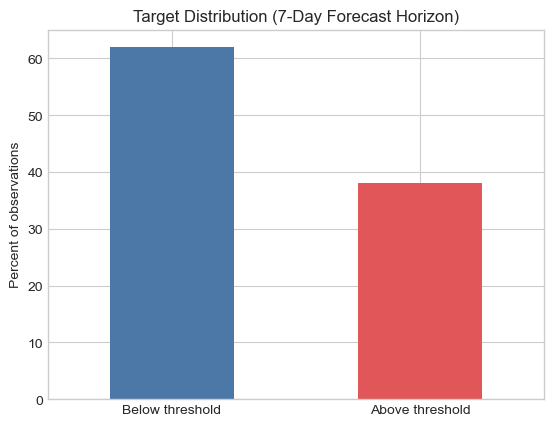

target
Below threshold    62.0
Above threshold    38.0
Name: proportion, dtype: float64

In [8]:
class_balance = (
    df['target']
    .value_counts(normalize=True)
    .rename(index={0: 'Below threshold', 1: 'Above threshold'})
    .mul(100)
    .round(1)
)

ax = class_balance.plot(kind='bar', color=['#4c78a8', '#e15759'], title=f'Target Distribution ({DAYS_AHEAD}-Day Forecast Horizon)')
ax.set_ylabel('Percent of observations')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.show()

class_balance

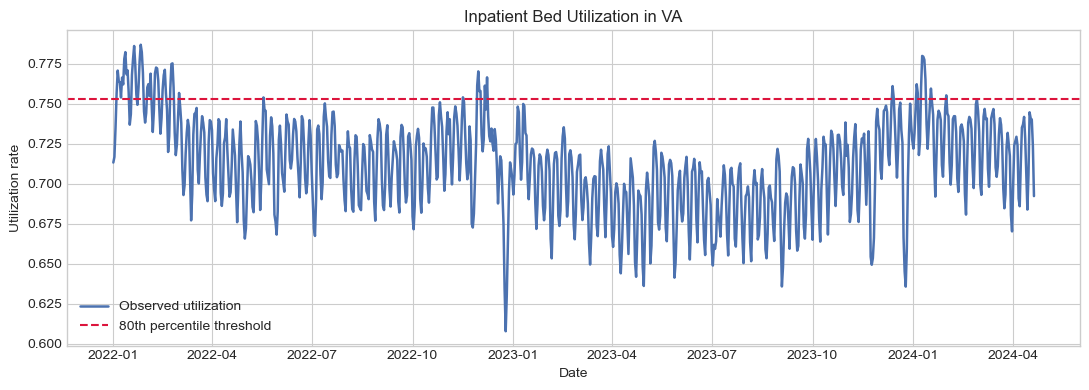

In [9]:
df_ex = df[df['state'] == EXAMPLE_STATE].copy()

plt.figure(figsize=(11, 4))
plt.plot(df_ex['date'], df_ex['inpatient_beds_utilization'], label='Observed utilization', linewidth=1.8)
plt.axhline(df_ex['state_threshold'].iloc[0], color='crimson', linestyle='--', label=f'{int(STATE_PERCENTILE * 100)}th percentile threshold')
plt.title(f'Inpatient Bed Utilization in {EXAMPLE_STATE}')
plt.ylabel('Utilization rate')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
missingness_pcts = (df.isna().mean().sort_values(ascending=False) * 100).round(1)
features_to_drop = missingness_pcts[missingness_pcts > (MISSINGNESS_PROP * 100)].index.to_list()

missingness_pcts.head(15)

google-symptoms_sum_anosmia_ageusia_smoothed_search             98.0
fb-survey_smoothed_wwearing_mask_7d                             79.1
fb-survey_smoothed_wcovid_vaccinated_appointment_or_accept      79.1
fb-survey_smoothed_wcli                                         79.1
fb-survey_smoothed_whh_cmnty_cli                                79.1
cases_roll_7                                                    49.3
jhu-csse_deaths_7dav_incidence_prop                             48.6
jhu-csse_confirmed_incidence_num                                48.6
chng_7dav_inpatient_covid                                       31.3
chng_smoothed_adj_outpatient_covid                               7.9
on_hand_supply_therapeutic_b_bamlanivimab_courses                7.1
previous_week_therapeutic_b_bamlanivimab_courses_used            7.0
previous_day_deaths_covid_and_influenza                          3.5
on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses     3.2
on_hand_supply_therapeutic_a_casir

### Feature Selection Rationale
Two Facebook survey features (`fb-survey_smoothed_wcli` and `fb-survey_smoothed_whh_cmnty_cli`) are excluded despite falling just under the 80% automatic missingness threshold. With ~79% of observations missing, median imputation would rely on only 21% of the data, making the imputed values statistically unreliable. The remaining features provide strong coverage of hospital capacity, COVID activity, and healthcare-seeking behavior.

In [11]:
df_model = df.drop(columns=features_to_drop).copy()

candidate_numeric_features = [
    'inpatient_beds_utilization',
    'inpatient_beds_used',
    'inpatient_beds_used_covid',
    'hhs_confirmed_admissions_covid_1d_prop_7dav',
    'jhu-csse_deaths_7dav_incidence_prop',
    'chng_smoothed_adj_outpatient_covid',
    'doctor-visits_smoothed_adj_cli',
    'staffed_adult_icu_bed_occupancy',
    'total_adult_patients_hosp_confirmed_covid',
    'critical_staffing_shortage_today_yes',
]

selected_numeric_features = [col for col in candidate_numeric_features if col in df_model.columns]
selected_numeric_features

['inpatient_beds_utilization',
 'inpatient_beds_used',
 'inpatient_beds_used_covid',
 'hhs_confirmed_admissions_covid_1d_prop_7dav',
 'jhu-csse_deaths_7dav_incidence_prop',
 'chng_smoothed_adj_outpatient_covid',
 'doctor-visits_smoothed_adj_cli',
 'staffed_adult_icu_bed_occupancy',
 'total_adult_patients_hosp_confirmed_covid',
 'critical_staffing_shortage_today_yes']

In [12]:
for lag in [1, 7, 14, 21, 28]:
    df_model[f'util_lag_{lag}'] = df_model.groupby('state')['inpatient_beds_utilization'].shift(lag)
    df_model[f'util_rollmean_{lag}'] = (
        df_model.groupby('state')['inpatient_beds_utilization']
        .transform(lambda s: s.shift(1).rolling(lag).mean())
    )

df_model['dist_from_threshold'] = df_model['inpatient_beds_utilization'] - df_model['state_threshold']
df_model['above_threshold_today'] = (df_model['dist_from_threshold'] > 0).astype(int)
df_model['days_since_start'] = (df_model['date'] - df_model['date'].min()).dt.days

feature_cols = selected_numeric_features + [
    'month', 'dayofweek', 'dayofyear', 'weekofyear',
    'dist_from_threshold', 'above_threshold_today', 'days_since_start'
] + [
    col for col in df_model.columns if col.startswith('util_lag_') or col.startswith('util_rollmean_')
]

model_df = df_model[['date', 'state', 'target'] + feature_cols].copy()
model_df = model_df.reset_index(drop=True).sort_values(['date', 'state']).reset_index(drop=True)

X = model_df[['state'] + feature_cols].copy()
y = model_df['target'].astype(int).copy()

numeric_features = [col for col in X.columns if col != 'state']
categorical_features = ['state']

print(f"Modeling dataset: {model_df.shape[0]:,} rows")
print(f"Features used: {len(numeric_features)} numeric + {len(categorical_features)} categorical")
model_df.head()

Modeling dataset: 42,891 rows
Features used: 27 numeric + 1 categorical


,date,state,target,inpatient_beds_utilization,inpatient_beds_used,inpatient_beds_used_covid,hhs_confirmed_admissions_covid_1d_prop_7dav,jhu-csse_deaths_7dav_incidence_prop,chng_smoothed_adj_outpatient_covid,doctor-visits_smoothed_adj_cli,...,util_lag_1,util_rollmean_1,util_lag_7,util_rollmean_7,util_lag_14,util_rollmean_14,util_lag_21,util_rollmean_21,util_lag_28,util_rollmean_28
0,2022-01-01,AK,1,0.725786,1154.0,51.0,0.937847,0.039527,2.051690,1.116240,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-01,AL,0,0.701753,10607.0,1103.0,3.349712,0.107400,4.459619,10.280280,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-01,AR,0,0.697321,6377.0,710.0,3.592026,0.575101,2.804376,8.672965,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-01,AZ,1,0.785031,13048.0,2383.0,4.155935,0.714151,2.436384,4.439173,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-01,CA,1,0.762113,48667.0,6787.0,2.480618,0.139707,4.285004,16.737195,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
model_df.isna().mean().sort_values(ascending=False).head(15)

jhu-csse_deaths_7dav_incidence_prop    0.486256
chng_smoothed_adj_outpatient_covid     0.078525
util_rollmean_28                       0.033294
util_lag_28                            0.033294
util_rollmean_21                       0.024970
util_lag_21                            0.024970
util_rollmean_14                       0.016647
util_lag_14                            0.016647
inpatient_beds_used_covid              0.009606
util_rollmean_7                        0.008323
util_lag_7                             0.008323
util_rollmean_1                        0.001189
util_lag_1                             0.001189
dist_from_threshold                    0.000000
days_since_start                       0.000000
dtype: float64

### Feature Correlation Heatmap
The heatmap below shows pairwise Pearson correlations among the core numeric features used in modeling. Highly correlated feature pairs (e.g., inpatient beds used vs. COVID patients hospitalized) are expected given the domain. We retain them because tree-based models handle multicollinearity well, and the logistic regression uses L2 regularization.

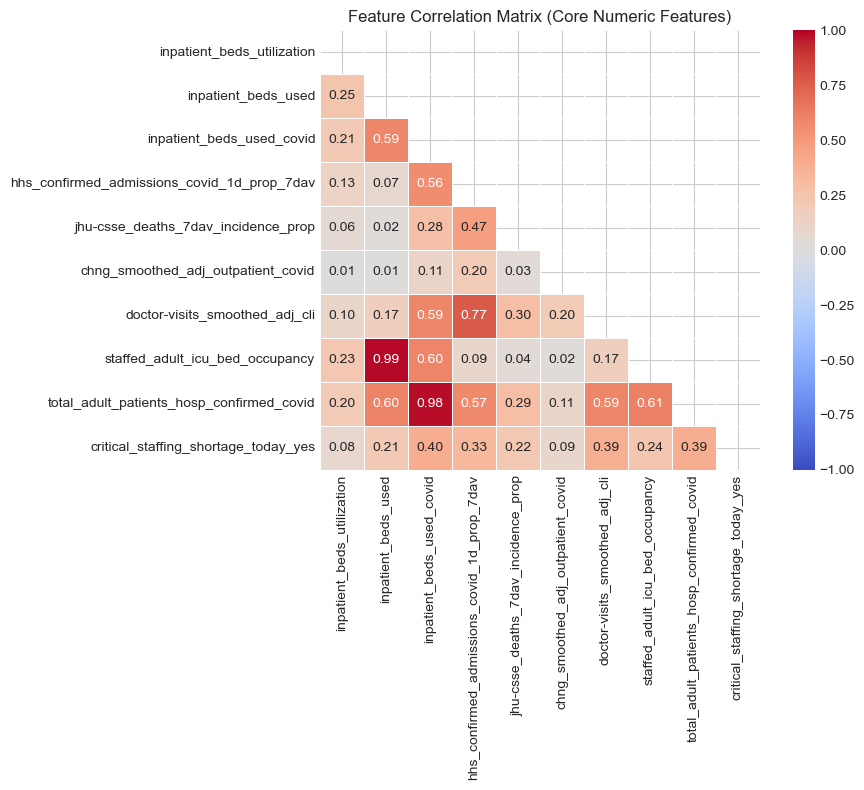

In [14]:
corr_matrix = model_df[selected_numeric_features].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix (Core Numeric Features)')
plt.tight_layout()
plt.show()

In [15]:
unique_dates = np.array(sorted(model_df['date'].unique()))
tscv = TimeSeriesSplit(n_splits=FOLDS)


def safe_roc_auc(y_true, scores):
    return roc_auc_score(y_true, scores) if y_true.nunique() > 1 else np.nan


def summarize_metrics(model_name, metric_rows):
    fold_df = pd.DataFrame(metric_rows)
    summary = (
        fold_df[['f1', 'precision', 'recall', 'balanced_accuracy', 'roc_auc']]
        .mean(numeric_only=True)
        .to_frame()
        .T
    )
    summary.insert(0, 'model', model_name)
    summary['folds'] = len(fold_df)
    return fold_df, summary


def run_baseline_cv(X, y):
    metric_rows = []
    last_fold = {}

    for fold, (_, test_idx) in enumerate(tscv.split(unique_dates), start=1):
        test_dates = unique_dates[test_idx]
        mask_test = model_df['date'].isin(test_dates)

        y_test = y.loc[mask_test]
        preds = X.loc[mask_test, 'above_threshold_today'].astype(int)
        scores = {
            'fold': fold,
            'f1': f1_score(y_test, preds, zero_division=0),
            'precision': precision_score(y_test, preds, zero_division=0),
            'recall': recall_score(y_test, preds, zero_division=0),
            'balanced_accuracy': balanced_accuracy_score(y_test, preds),
            'roc_auc': safe_roc_auc(y_test, preds),
        }
        metric_rows.append(scores)
        last_fold = {
            'y_test': y_test,
            'preds': preds.values,
            'probs': preds.values.astype(float),
            'mask_test': mask_test,
        }

    fold_df, summary = summarize_metrics('Baseline: current status persists', metric_rows)
    return fold_df, summary, last_fold


def run_model_cv(model_name, estimator, balance_classes=False):
    metric_rows = []
    last_fold = {}

    for fold, (train_idx, test_idx) in enumerate(tscv.split(unique_dates), start=1):
        train_dates = unique_dates[train_idx]
        test_dates = unique_dates[test_idx]

        mask_train = model_df['date'].isin(train_dates)
        mask_test = model_df['date'].isin(test_dates)

        X_train = X.loc[mask_train]
        y_train = y.loc[mask_train]
        X_test = X.loc[mask_test]
        y_test = y.loc[mask_test]

        fit_kwargs = {}
        if balance_classes:
            sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)
            if isinstance(estimator, Pipeline):
                fit_kwargs['model__sample_weight'] = sample_weight
            else:
                fit_kwargs['sample_weight'] = sample_weight

        estimator.fit(X_train, y_train, **fit_kwargs)
        preds = estimator.predict(X_test)

        probs = None
        try:
            probs = estimator.predict_proba(X_test)[:, 1]
            roc_auc = safe_roc_auc(y_test, probs)
        except Exception:
            roc_auc = np.nan

        scores = {
            'fold': fold,
            'f1': f1_score(y_test, preds, zero_division=0),
            'precision': precision_score(y_test, preds, zero_division=0),
            'recall': recall_score(y_test, preds, zero_division=0),
            'balanced_accuracy': balanced_accuracy_score(y_test, preds),
            'roc_auc': roc_auc,
        }
        metric_rows.append(scores)
        last_fold = {
            'y_test': y_test,
            'preds': preds,
            'probs': probs if probs is not None else preds.astype(float),
            'mask_test': mask_test,
        }

    fold_df, summary = summarize_metrics(model_name, metric_rows)
    return fold_df, summary, last_fold

## Baseline Model

In [16]:
baseline_fold_results, baseline_summary, baseline_last_fold = run_baseline_cv(X, y)
baseline_summary.round(3)

,model,f1,precision,recall,balanced_accuracy,roc_auc,folds
0,Baseline: current status persists,0.832,0.832,0.832,0.863,0.863,5


## Stronger Benchmark: Regularized Logistic Regression

In [17]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)

categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

logistic_model = Pipeline(
    steps=[
        ('preprocess', ColumnTransformer(
            transformers=[
                ('num', numeric_transformer, numeric_features),
                ('cat', categorical_transformer, categorical_features),
            ]
        )),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
    ]
)

In [18]:
logistic_fold_results, logistic_summary, logistic_last_fold = run_model_cv('Logistic Regression', logistic_model)
logistic_summary.round(3)

,model,f1,precision,recall,balanced_accuracy,roc_auc,folds
0,Logistic Regression,0.8,0.788,0.84,0.854,0.933,5


## Tree-Based Bagging Model

In [19]:
bagging_dict = {}
for e in range(100, 300, 100):
    for d in range(3, 8):
        for mss in range(2, 4):
            for msl in [1, 5, 10, 15, 20]:
                bagging_model = Pipeline(
                    steps=[
                        ('preprocess', ColumnTransformer(
                            transformers=[
                                ('num', SimpleImputer(strategy='median'), numeric_features),
                                ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
                            ]
                        )),
                        ('model', RandomForestClassifier(
                            n_estimators=e,
                            max_depth=d,
                            min_samples_split=mss,
                            min_samples_leaf=msl,
                            random_state=RANDOM_STATE,
                        )),
                    ]
                )

                bagging_fold_results, bagging_summary, bagging_last_fold = run_model_cv(
                    'RandomForestClassifier',
                    bagging_model,
                    balance_classes=True,
                )
                key = (f"{e} Estimators", f"{d} Max Depth", f"{mss} Min Samples Split", f"{msl} Min Samples Leaf")
                bagging_dict[key] = bagging_summary['f1']

In [20]:
params = None
metric_value = 0

for k, v in bagging_dict.items():
    v_ = v.values[0]
    if v_ > metric_value:
        metric_value = v_
        params = k

print(params)

('100 Estimators', '7 Max Depth', '2 Min Samples Split', '5 Min Samples Leaf')


In [21]:
bagging_model = Pipeline(
    steps=[
        ('preprocess', ColumnTransformer(
            transformers=[
                ('num', SimpleImputer(strategy='median'), numeric_features),
                ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
            ]
        )),
        ('model', RandomForestClassifier(
            n_estimators=100,
            max_depth=7,
            min_samples_split=2,
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
        )),
    ]
)

bagging_fold_results, bagging_summary, bagging_last_fold = run_model_cv(
    'RandomForestClassifier',
    bagging_model,
    balance_classes=True,
)
bagging_summary.round(3)

,model,f1,precision,recall,balanced_accuracy,roc_auc,folds
0,RandomForestClassifier,0.839,0.826,0.852,0.87,0.94,5


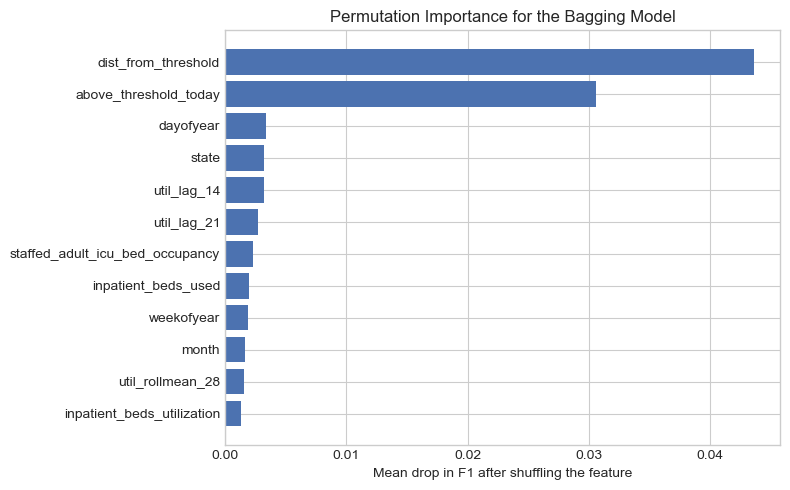

,feature,importance
15,dist_from_threshold,0.043581
16,above_threshold_today,0.030573
13,dayofyear,0.003368
0,state,0.003171
22,util_lag_14,0.003167
24,util_lag_21,0.002681
8,staffed_adult_icu_bed_occupancy,0.002266
2,inpatient_beds_used,0.001965
14,weekofyear,0.001917
11,month,0.001663


In [22]:
full_sample_weight = compute_sample_weight(class_weight='balanced', y=y)
bagging_model.fit(X, y, model__sample_weight=full_sample_weight)

importance = permutation_importance(
    bagging_model,
    X,
    y,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring='f1',
)

importance_df = (
    pd.DataFrame({
        'feature': X.columns,
        'importance': importance.importances_mean,
    })
    .sort_values('importance', ascending=False)
    .head(12)
)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1])
plt.title('Permutation Importance for the Bagging Model')
plt.xlabel('Mean drop in F1 after shuffling the feature')
plt.tight_layout()
plt.show()

importance_df

## Tree-Based Boosting Model

In [23]:
boosting_dict = {}
for lr in [0.04, 0.05, 0.06]:
    for d in range(3, 8):
        for mi in range(200, 300, 50):
            for msl in [1, 5, 10, 15, 20]:
                boosting_model = Pipeline(
                    steps=[
                        ('preprocess', ColumnTransformer(
                            transformers=[
                                ('num', SimpleImputer(strategy='median'), numeric_features),
                                ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
                            ]
                        )),
                        ('model', HistGradientBoostingClassifier(
                            learning_rate=lr,
                            max_depth=d,
                            max_iter=mi,
                            min_samples_leaf=msl,
                            random_state=RANDOM_STATE,
                        )),
                    ]
                )

                boosting_fold_results, boosting_summary, boosting_last_fold = run_model_cv(
                    'HistGradientBoosting',
                    boosting_model,
                    balance_classes=True,
                )
                key = (f"{lr} Learning Rate", f"{d} Max Depth", f"{mi} Max Iter", f"{msl} Min Samples Leaf")
                boosting_dict[key] = boosting_summary['f1']

In [24]:
params = None
metric_value = 0

for k, v in boosting_dict.items():
    v_ = v.values[0]
    if v_ > metric_value:
        metric_value = v_
        params = k

print(params)

('0.06 Learning Rate', '5 Max Depth', '250 Max Iter', '15 Min Samples Leaf')


### Hyperparameter Choices

Class imbalance is handled via `compute_sample_weight('balanced', ...)`, which upweights the minority class during training (equivalent to the `class_weight='balanced'` approach used in logistic regression).

In [25]:
boosting_model = Pipeline(
    steps=[
        ('preprocess', ColumnTransformer(
            transformers=[
                ('num', SimpleImputer(strategy='median'), numeric_features),
                ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
            ]
        )),
        ('model', HistGradientBoostingClassifier(
            learning_rate=0.06,
            max_depth=5,
            max_iter=250,
            min_samples_leaf=15,
            random_state=RANDOM_STATE,
        )),
    ]
)

boosting_fold_results, boosting_summary, boosting_last_fold = run_model_cv(
    'HistGradientBoosting',
    boosting_model,
    balance_classes=True,
)
boosting_summary.round(3)

,model,f1,precision,recall,balanced_accuracy,roc_auc,folds
0,HistGradientBoosting,0.848,0.83,0.872,0.881,0.953,5


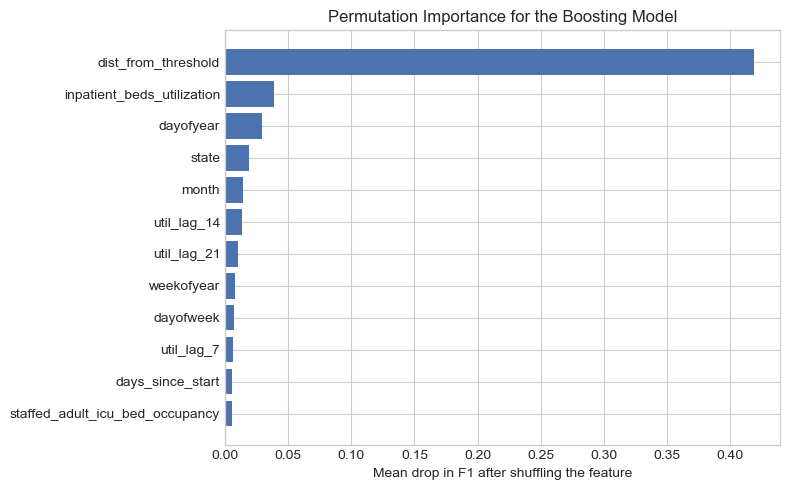

,feature,importance
15,dist_from_threshold,0.418675
1,inpatient_beds_utilization,0.038815
13,dayofyear,0.029224
0,state,0.019295
11,month,0.014168
22,util_lag_14,0.013544
24,util_lag_21,0.010516
14,weekofyear,0.007505
12,dayofweek,0.006984
20,util_lag_7,0.006125


In [26]:
full_sample_weight = compute_sample_weight(class_weight='balanced', y=y)
boosting_model.fit(X, y, model__sample_weight=full_sample_weight)

importance = permutation_importance(
    boosting_model,
    X,
    y,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring='f1',
)

importance_df = (
    pd.DataFrame({
        'feature': X.columns,
        'importance': importance.importances_mean,
    })
    .sort_values('importance', ascending=False)
    .head(12)
)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1])
plt.title('Permutation Importance for the Boosting Model')
plt.xlabel('Mean drop in F1 after shuffling the feature')
plt.tight_layout()
plt.show()

importance_df

In [27]:
model_summary = pd.concat([
    baseline_summary,
    logistic_summary,
    bagging_summary,
    boosting_summary,
], ignore_index=True)

model_summary = model_summary.sort_values('f1', ascending=False).reset_index(drop=True)
model_summary.round(3)

,model,f1,precision,recall,balanced_accuracy,roc_auc,folds
0,HistGradientBoosting,0.848,0.830,0.872,0.881,0.953,5
1,RandomForestClassifier,0.839,0.826,0.852,0.870,0.940,5
2,Baseline: current status persists,0.832,0.832,0.832,0.863,0.863,5
3,Logistic Regression,0.800,0.788,0.840,0.854,0.933,5


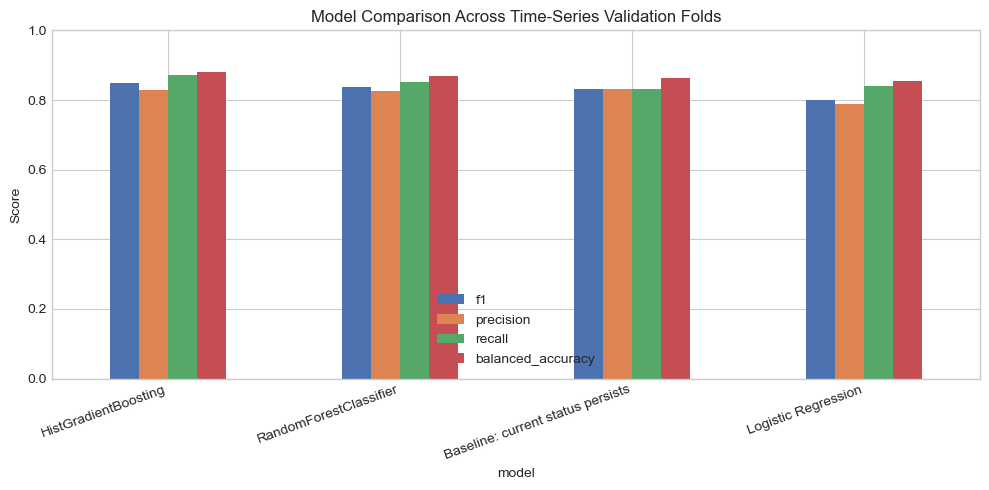

Recommended model for the report: HistGradientBoosting


In [28]:
plot_df = model_summary.set_index('model')[['f1', 'precision', 'recall', 'balanced_accuracy']]
plot_df.plot(kind='bar', figsize=(10, 5))
plt.title('Model Comparison Across Time-Series Validation Folds')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

best_model = model_summary.iloc[0]['model']
print(f"Recommended model for the report: {best_model}")

## Error Analysis

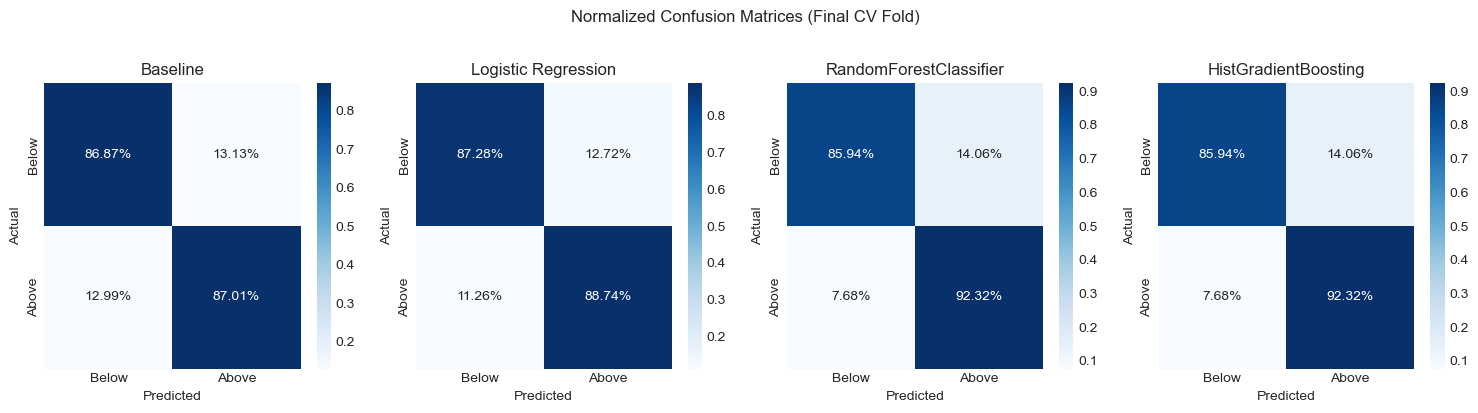

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

models_eval = [
    ('Baseline', baseline_last_fold),
    ('Logistic Regression', logistic_last_fold),
    ('RandomForestClassifier', boosting_last_fold),
    ('HistGradientBoosting', boosting_last_fold),
]

for ax, (name, fold_data) in zip(axes, models_eval):
    cm = confusion_matrix(fold_data['y_test'], fold_data['preds'], normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', ax=ax,
                xticklabels=['Below', 'Above'], yticklabels=['Below', 'Above'])
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Normalized Confusion Matrices (Final CV Fold)', y=1.02)
plt.tight_layout()
plt.show()

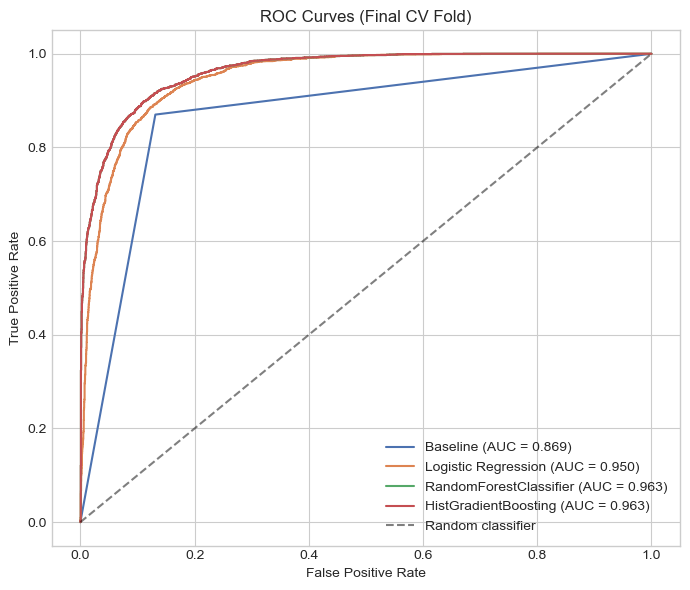

In [30]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, fold_data in models_eval:
    fpr, tpr, _ = roc_curve(fold_data['y_test'], fold_data['probs'])
    auc_val = roc_auc_score(fold_data['y_test'], fold_data['probs'])
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (Final CV Fold)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Per-State F1 Scores
The chart below shows how the best model (HistGradientBoosting) performs across individual states on the final CV fold. States where the model struggles may warrant additional features or separate modeling.

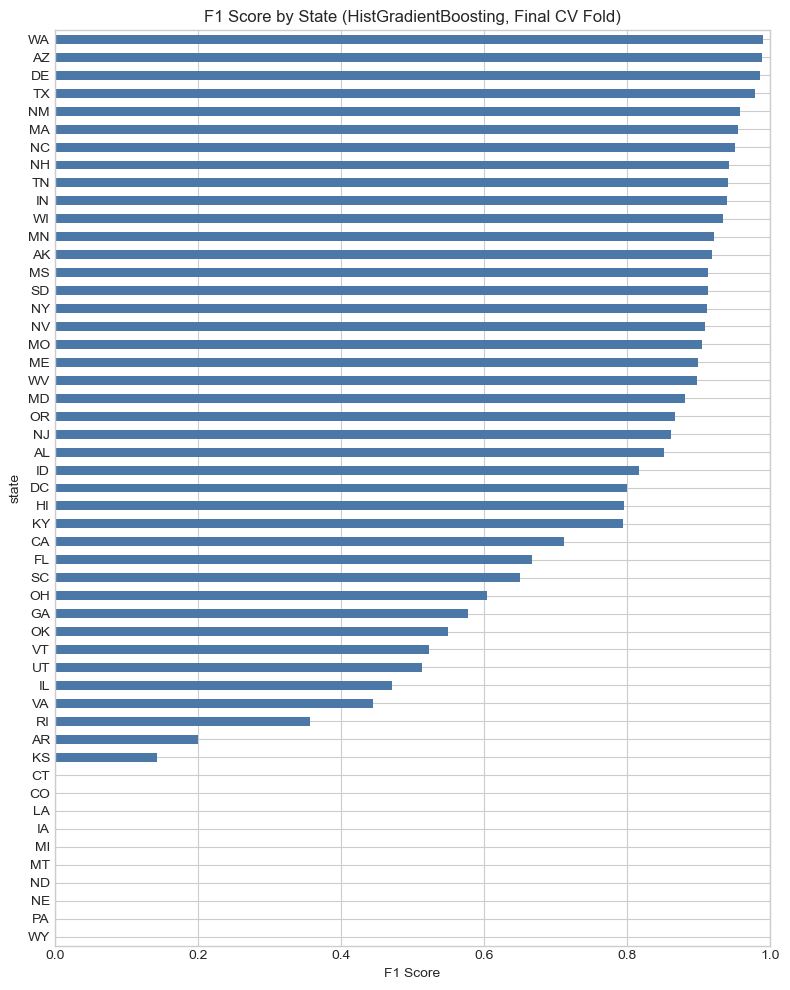

States with F1 < 0.5: ['WY', 'PA', 'NE', 'ND', 'MT', 'MI', 'IA', 'LA', 'CO', 'CT', 'KS', 'AR', 'RI', 'VA', 'IL']
Median state-level F1: 0.800


In [31]:
mask = boosting_last_fold['mask_test']
state_perf = pd.DataFrame({
    'state': model_df.loc[mask, 'state'].values,
    'y_true': boosting_last_fold['y_test'].values,
    'y_pred': boosting_last_fold['preds'],
})

state_f1 = (
    state_perf.groupby('state')
    .apply(lambda g: f1_score(g['y_true'], g['y_pred'], zero_division=0))
    .sort_values()
    .rename('f1')
)

fig, ax = plt.subplots(figsize=(8, 10))
state_f1.plot(kind='barh', ax=ax, color='#4c78a8')
ax.set_title('F1 Score by State (HistGradientBoosting, Final CV Fold)')
ax.set_xlabel('F1 Score')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

print(f"States with F1 < 0.5: {state_f1[state_f1 < 0.5].index.tolist()}")
print(f"Median state-level F1: {state_f1.median():.3f}")

In [32]:
best_row = model_summary.iloc[0]
baseline_row = model_summary[model_summary['model'].str.startswith('Baseline')].iloc[0]

print(f"Verified sample: {model_df.shape[0]:,} state-day observations across {model_df['state'].nunique()} states.")
print(
    f"Best model: {best_row['model']} | "
    f"F1={best_row['f1']:.3f}, precision={best_row['precision']:.3f}, "
    f"recall={best_row['recall']:.3f}, balanced accuracy={best_row['balanced_accuracy']:.3f}."
)
print(
    f"Improvement over the persistence baseline: "
    f"ΔF1={best_row['f1'] - baseline_row['f1']:.3f}, "
    f"Δrecall={best_row['recall'] - baseline_row['recall']:.3f}."
)
print("Top features:", ", ".join(importance_df['feature'].head(5).tolist()))

Verified sample: 42,891 state-day observations across 51 states.
Best model: HistGradientBoosting | F1=0.848, precision=0.830, recall=0.872, balanced accuracy=0.881.
Improvement over the persistence baseline: ΔF1=0.016, Δrecall=0.040.
Top features: dist_from_threshold, inpatient_beds_utilization, dayofyear, state, month
